# Implied Volatility & Volatility Surface — Demo Project

## 1. Business question

How can we recover **implied volatility (IV)** from option prices and visualize the **volatility surface** across strikes and maturities?

This is a core task in:

- Options trading
- Derivatives risk management
- Volatility modeling & pricing

---

## 2. Project steps

1. Create a synthetic grid of European call option prices with a non-flat volatility surface.
2. Implement a numerical **implied volatility solver** (bisection method).
3. Recover IV from prices and validate it against the true (simulated) volatility.
4. Visualize:
   - Volatility smiles (IV vs strike for different maturities)
   - A 3D **volatility surface** (strike × maturity × IV)
5. Summarize key insights and intuition.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

np.random.seed(42)

# Base market parameters
S0 = 100        # underlying price
r = 0.02        # risk-free rate

## 3. Black–Scholes setup

We work with **European call options** and use the Black–Scholes formula to:

- Generate synthetic "market" option prices
- Later invert prices back into implied volatility

We first implement:

- Standard normal CDF
- Black–Scholes d1, d2
- Call price function

In [2]:
# Standard normal CDF using erf (no SciPy needed)
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def bs_d1(S, K, r, sigma, T):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, r, sigma, T):
    return bs_d1(S, K, r, sigma, T) - sigma * np.sqrt(T)

def bs_call_price(S, K, r, sigma, T):
    """Black–Scholes price of a European call."""
    if T <= 0:
        return max(S - K, 0.0)
    d1 = bs_d1(S, K, r, sigma, T)
    d2 = bs_d2(S, K, r, sigma, T)
    return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)

## 4. Simulate a synthetic volatility surface

To keep things simple (no data download), we **simulate** a realistic-looking volatility surface.

We create a function σ(K, T) that:

- Has a **smile** in strike (higher vols away from at-the-money)
- Increases slightly with maturity T

Then we:

1. Build a grid of strikes K and maturities T.
2. Compute the "true" σ(K, T).
3. Use Black–Scholes to get the corresponding call prices.

In [3]:
# Grid of strikes and maturities
strikes = np.arange(70, 131, 5)          # 70, 75, ..., 130
maturities = np.array([0.25, 0.5, 1.0, 2.0])  # 3m, 6m, 1y, 2y

def true_vol_surface(K, T, S_ref=100):
    """Synthetic 'true' volatility surface with smile + term structure."""
    moneyness = K / S_ref
    base = 0.18
    smile = 0.25 * (moneyness - 1.0) ** 2
    term = 0.05 * np.sqrt(T)
    return base + smile + term

rows = []
for T in maturities:
    for K in strikes:
        sigma_true = true_vol_surface(K, T, S0)
        call_price = bs_call_price(S0, K, r, sigma_true, T)

        # Optional: add tiny noise to mimic market microstructure
        noise = np.random.normal(0, 0.02)
        call_price_noisy = max(call_price + noise, 0.01)

        rows.append({
            "K": K,
            "T": T,
            "sigma_true": sigma_true,
            "call_price": call_price_noisy
        })

options_df = pd.DataFrame(rows)
options_df.head()

,K,T,sigma_true,call_price
0,70,0.25,0.227500,30.360955
1,75,0.25,0.220625,25.383045
2,80,0.25,0.215000,20.470214
3,85,0.25,0.210625,15.684257
4,90,0.25,0.207500,11.167027


## 5. Implied volatility solver (bisection method)

Given a market option price, we want to find the σ such that:


We implement a **bisection method**:

- Start with a low and high bound for σ (e.g. 0.01 to 1.5).
- Repeatedly narrow the interval until the model price matches the market price within a tolerance.
- This is robust and only requires the price being monotonic in σ (which it is).

In [4]:
def implied_vol_bisection(C_mkt, S, K, r, T, 
                          sigma_low=0.01, sigma_high=1.5, 
                          tol=1e-4, max_iter=100):
    """Solve for implied volatility using bisection."""
    # Handle edge case: zero or very small price
    if C_mkt < max(S - K * np.exp(-r*T), 0.0) + 1e-8:
        return np.nan

    low = sigma_low
    high = sigma_high

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        price_mid = bs_call_price(S, K, r, mid, T)

        # bisection step
        if price_mid > C_mkt:
            high = mid
        else:
            low = mid

        if abs(high - low) < tol:
            return mid

    return mid  # last estimate if max_iter reached

# Apply IV solver to each row
iv_list = []
for _, row in options_df.iterrows():
    iv = implied_vol_bisection(
        row["call_price"], 
        S0, 
        row["K"], 
        r, 
        row["T"]
    )
    iv_list.append(iv)

options_df["sigma_iv"] = iv_list
options_df.head()

,K,T,sigma_true,call_price,sigma_iv
0,70,0.25,0.227500,30.360955,0.267822
1,75,0.25,0.220625,25.383045,0.214711
2,80,0.25,0.215000,20.470214,0.221441
3,85,0.25,0.210625,15.684257,0.216348
4,90,0.25,0.207500,11.167027,0.207072


## 6. Sanity check: Implied vol vs true vol

We compare:

- **σ_true** — the volatility we used to generate prices
- **σ_iv** — the volatility recovered from prices via the bisection solver

We expect them to match closely (up to small numerical error and noise).

Mean Absolute Error between true σ and implied σ: 0.0023


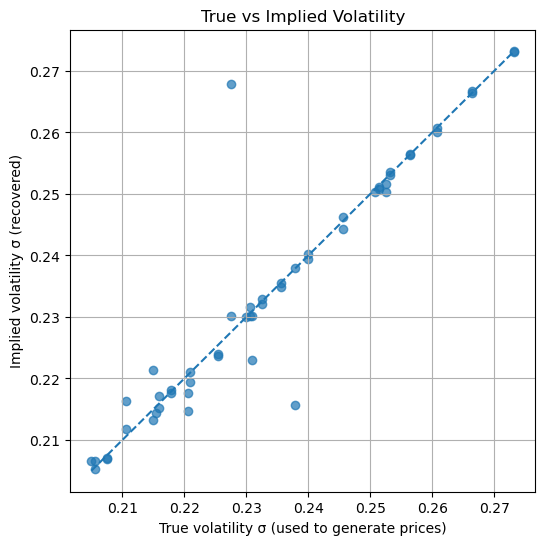

In [5]:
# Drop any rows where IV failed
valid_df = options_df.dropna(subset=["sigma_iv"]).copy()

mae = np.mean(np.abs(valid_df["sigma_iv"] - valid_df["sigma_true"]))
print(f"Mean Absolute Error between true σ and implied σ: {mae:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(valid_df["sigma_true"], valid_df["sigma_iv"], alpha=0.7)
plt.plot([valid_df["sigma_true"].min(), valid_df["sigma_true"].max()],
         [valid_df["sigma_true"].min(), valid_df["sigma_true"].max()],
         linestyle="--")
plt.xlabel("True volatility σ (used to generate prices)")
plt.ylabel("Implied volatility σ (recovered)")
plt.title("True vs Implied Volatility")
plt.grid(True)
plt.show()

## 7. Volatility smiles (IV vs strike)

We now plot **IV vs strike** for each maturity T:

- Each line represents a fixed maturity.
- The smile shape shows how IV changes with moneyness.

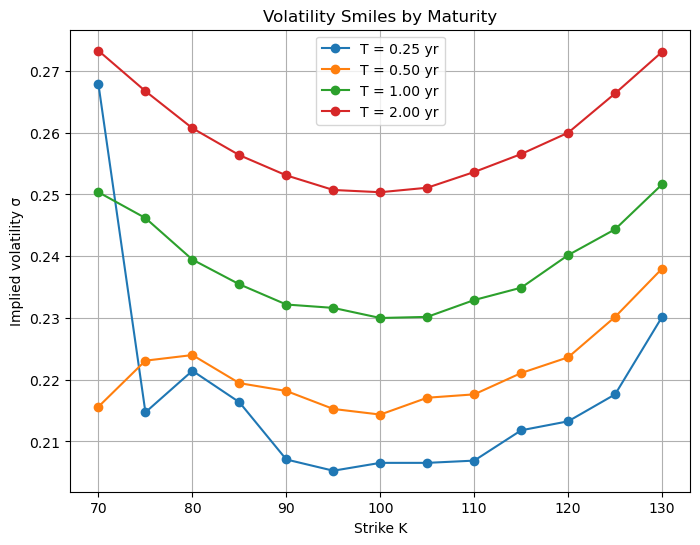

In [6]:
plt.figure(figsize=(8,6))

for T in maturities:
    sub = valid_df[valid_df["T"] == T]
    plt.plot(sub["K"], sub["sigma_iv"], marker="o", label=f"T = {T:.2f} yr")

plt.xlabel("Strike K")
plt.ylabel("Implied volatility σ")
plt.title("Volatility Smiles by Maturity")
plt.legend()
plt.grid(True)
plt.show()

## 8. 3D volatility surface

Finally, we visualize the **volatility surface**:

- x-axis: Strike K  
- y-axis: Maturity T  
- z-axis: Implied volatility σ  

This is a standard visualization on options desks to understand the structure of market-implied volatility.

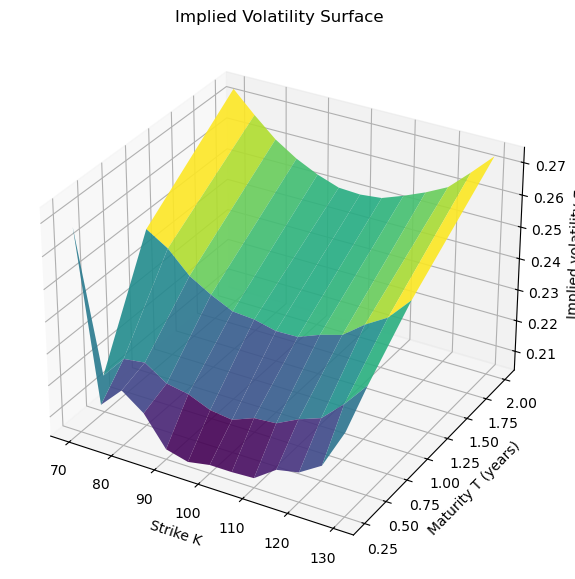

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# Pivot the table into a grid for plotting
pivot_iv = valid_df.pivot(index="T", columns="K", values="sigma_iv")
T_grid = pivot_iv.index.values
K_grid = pivot_iv.columns.values
T_mesh, K_mesh = np.meshgrid(T_grid, K_grid, indexing="ij")
IV_mesh = pivot_iv.values

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(K_mesh, T_mesh, IV_mesh, cmap="viridis", edgecolor="none", alpha=0.9)

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("Implied volatility σ")
ax.set_title("Implied Volatility Surface")
plt.show()

 What the data shows

 
	•	Volatility smile:
IV is lowest near-the-money (K ≈ S₀) and increases for deep OTM/ITM strikes.
This reflects higher perceived tail-risk — a common feature in equity options.


	•	Term structure:
IV generally increases with maturity.
Longer horizons capture more uncertainty, leading to a gently upward-sloping volatility term structure.


	•	3D volatility surface:
Combining smiles and term structure produces a smooth, realistic surface where:


	•	Strike drives curvature (smile)

    
	•	Maturity drives height (term structure)

    
This surface is essential for pricing exotic options, managing vega exposure, and calibrating stochastic volatility models.
